# Ridge Regression — L2 Regularization

**Ridge** minimizes:

> Loss = Σ(y − ŷ)² + α · Σwᵢ²

The **L2 penalty** (α · Σwᵢ²) shrinks all coefficients toward zero smoothly. Unlike Lasso (L1), **no coefficient is ever driven to exactly zero** — Ridge keeps all features active but dampens their influence.

**When Ridge outperforms plain Linear Regression:**
- Many correlated features (e.g. 200+ one-hot route dummies) — Ridge prevents coefficient blow-up
- Multicollinearity in the feature matrix — Ridge's closed-form solution is always numerically stable

| alpha | Effect |
|-------|--------|
| 0 | Equivalent to plain Linear Regression |
| small | Light shrinkage, coefficients close to OLS |
| large | Heavy shrinkage, all coefficients approach zero |

**Target:** `average_load` — average passengers on a bus after leaving a stop.

In [9]:
# Ridge Regression — L2 Regularization
# L2 penalty: loss + alpha * sum(w^2)
# Key property: shrinks all coefficients toward zero smoothly, none go exactly to zero
# Contrast with Lasso (L1): Ridge keeps all features but damps them; Lasso eliminates them
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().parent.parent
DB_PATH = PROJECT_ROOT / 'dataset' / 'Ridership_v1.sqlite'
print('DB path:', DB_PATH)
print('Exists:', DB_PATH.exists())

save_dir = PROJECT_ROOT / 'diagram' / 'model'
save_dir.mkdir(parents=True, exist_ok=True)

DB path: /Users/yusheng/Developer/CS-506-final-project/dataset/Ridership_v1.sqlite
Exists: True


## 1. Load Data

In [10]:
# Load data
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT season, route_name, stop_sequence, direction_id,
           day_type_name, time_period_name,
           average_ons, average_offs, average_load, num_trips
    FROM MBTA_Ridership
    WHERE average_load IS NOT NULL
""", conn)
conn.close()
print(f'Loaded {len(df)} rows')

Loaded 1038340 rows


## 2. Clean & Feature Engineering

Same cleaning pipeline as Lasso for a fair comparison.

In [11]:
# Clean + feature engineering
df = df[df['average_offs'] >= 0]
df['day_type_name']    = df['day_type_name'].astype(str).str.strip().str.lower()
df['route_name']       = df['route_name'].astype(str).str.strip()
df['time_period_name'] = df['time_period_name'].astype(str).str.strip()

df['season_year'] = df['season'].str.extract(r'(\d{4})')[0].astype(float)
df = df.dropna(subset=['season_year', 'average_load'])
df['season_year'] = df['season_year'].astype(int)

print(f'Rows after cleaning: {len(df)}')
print(f'Unique routes: {df["route_name"].nunique()}')
print(f'Season years: {sorted(df["season_year"].unique())}')

Rows after cleaning: 1038337
Unique routes: 162
Season years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 3. Feature Setup & Chronological Split

Same chronological split as Lasso:

- **Train:** seasons ≤ 2022  
- **Val:** 2023 — used only to pick the best `alpha`  
- **Test:** 2024 — held out until final evaluation

In [12]:
# Feature setup + chronological split
# train <= 2022, val = 2023, test = 2024 (simulates predicting future seasons)
CAT_FEATURES = ['route_name', 'day_type_name', 'time_period_name']
NUM_FEATURES = ['stop_sequence', 'direction_id', 'season_year',
                'average_ons', 'average_offs', 'num_trips']
TARGET = 'average_load'
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

train = df[df['season_year'] <= 2022]
val   = df[df['season_year'] == 2023]
test  = df[df['season_year'] == 2024]

X_train, y_train = train[ALL_FEATURES], train[TARGET]
X_val,   y_val   = val[ALL_FEATURES],   val[TARGET]
X_test,  y_test  = test[ALL_FEATURES],  test[TARGET]

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 827439  Val: 105480  Test: 105418


## 4. Tune Alpha on Validation Set

Ridge is typically **less sensitive to alpha** than Lasso, so we explore a wider log-spaced range (0.01 → 5000). Increasing alpha never eliminates features — it only compresses them.

In [13]:
# Preprocessing + alpha sweep on validation
preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
])

def make_ridge(alpha):
    return Pipeline([
        ('prep', preprocessor),
        ('ridge', Ridge(alpha=alpha)),
    ])

# Ridge is less sensitive to alpha than Lasso — explore a wider log range
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 5000.0]
val_maes = []

for a in alphas:
    pipe = make_ridge(a)
    pipe.fit(X_train, y_train)
    mae = mean_absolute_error(y_val, pipe.predict(X_val))
    val_maes.append(mae)
    print(f'  alpha={a:<8}  Val MAE: {mae:.3f}')

best_alpha = alphas[int(np.argmin(val_maes))]
print(f'\nBest alpha: {best_alpha}')

  alpha=0.01      Val MAE: 4.775
  alpha=0.1       Val MAE: 4.776
  alpha=1.0       Val MAE: 4.775
  alpha=10.0      Val MAE: 4.775
  alpha=100.0     Val MAE: 4.767
  alpha=500.0     Val MAE: 4.746
  alpha=1000.0    Val MAE: 4.732
  alpha=5000.0    Val MAE: 4.750

Best alpha: 1000.0


## 6. Final Model & Metrics

Evaluate under all three error norms:

| Metric | Norm | Measures |
|--------|------|----------|
| MAE | L1 | Average absolute error |
| RMSE | L2 | Penalises large errors more than small ones |
| Max Error | L∞ | Single worst-case prediction on the test set |

In [14]:
# Final model + metrics under all three norms
# L1 norm error = MAE, L2 norm error = RMSE, L-inf norm error = max absolute error
final_model = make_ridge(best_alpha)
final_model.fit(X_train, y_train)

val_preds  = final_model.predict(X_val)
test_preds = final_model.predict(X_test)

val_mae   = mean_absolute_error(y_val, val_preds)
val_rmse  = root_mean_squared_error(y_val, val_preds)
val_linf  = float(np.max(np.abs(y_val.values - val_preds)))

test_mae  = mean_absolute_error(y_test, test_preds)
test_rmse = root_mean_squared_error(y_test, test_preds)
test_linf = float(np.max(np.abs(y_test.values - test_preds)))

print(f'\n{"="*60}')
print(f'Ridge (alpha={best_alpha})')
print(f'  Val   MAE(L1): {val_mae:.3f}   RMSE(L2): {val_rmse:.3f}   MaxErr(Linf): {val_linf:.3f}')
print(f'  Test  MAE(L1): {test_mae:.3f}   RMSE(L2): {test_rmse:.3f}   MaxErr(Linf): {test_linf:.3f}')
print(f'{"="*60}')


Ridge (alpha=1000.0)
  Val   MAE(L1): 4.732   RMSE(L2): 6.854   MaxErr(Linf): 73.436
  Test  MAE(L1): 5.306   RMSE(L2): 7.472   MaxErr(Linf): 84.355


## 8. Actual vs Predicted (2024 Test Set)

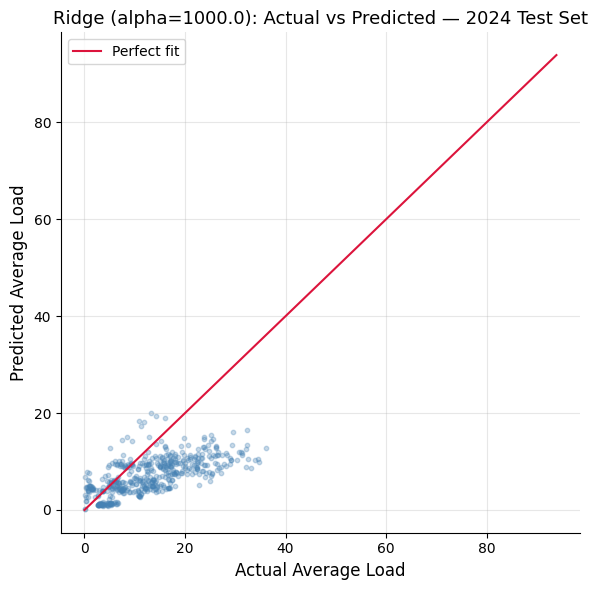

Saved: ridge_actual_vs_predicted.png


In [15]:
# Plot: Actual vs Predicted (2024 test set)
sample = min(500, len(y_test))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values[:sample], test_preds[:sample],
           alpha=0.3, s=10, color='steelblue')
ax.plot([0, y_test.max()], [0, y_test.max()],
        color='crimson', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Average Load', fontsize=12)
ax.set_ylabel('Predicted Average Load', fontsize=12)
ax.set_title(f'Ridge (alpha={best_alpha}): Actual vs Predicted — 2024 Test Set', fontsize=13)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'ridge_actual_vs_predicted.png', dpi=150)
plt.show()
print('Saved: ridge_actual_vs_predicted.png')

## 9. Residual Analysis

A **residual** is `actual − predicted`. Plotting residuals against predicted values reveals systematic errors:
- Random scatter around 0 → model has no systematic bias
- Fan shape (residuals grow with predicted value) → heteroscedasticity, common in count data like ridership

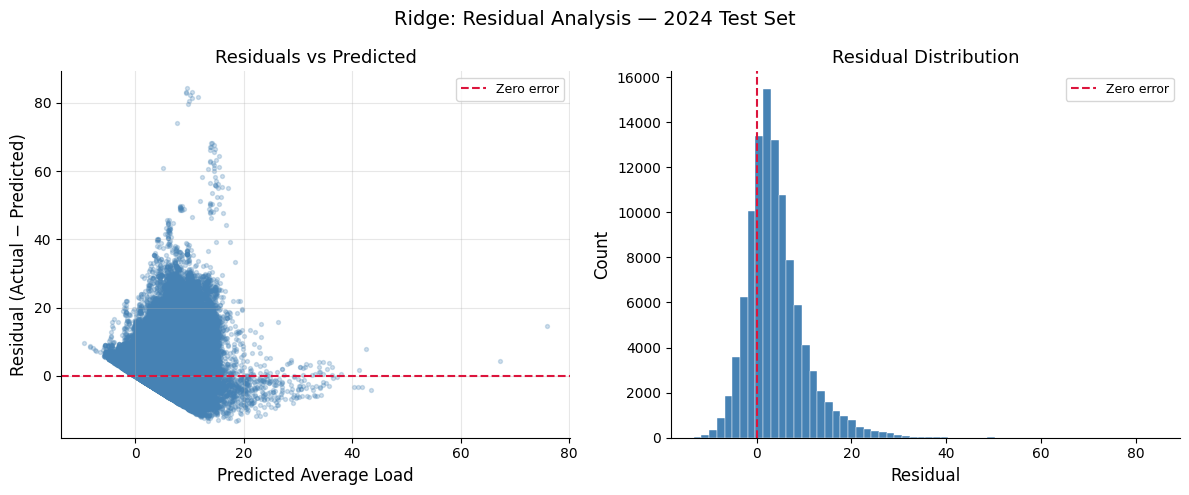

Saved: ridge_residuals.png


In [16]:
# Residual plot: where does Ridge go wrong?
residuals = y_test.values - test_preds

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(test_preds, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--', label='Zero error')
axes[0].set_xlabel('Predicted Average Load', fontsize=12)
axes[0].set_ylabel('Residual (Actual − Predicted)', fontsize=12)
axes[0].set_title('Residuals vs Predicted', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='crimson', linewidth=1.5, linestyle='--', label='Zero error')
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Ridge: Residual Analysis — 2024 Test Set', fontsize=14)
plt.tight_layout()
plt.savefig(save_dir / 'ridge_residuals.png', dpi=150)
plt.show()
print('Saved: ridge_residuals.png')

## 10. Coefficient Shrinkage Path

Shows how all coefficients shrink as `alpha` grows. Unlike Lasso, **no line ever reaches zero** — Ridge uniformly damps everything. Compare this to the Lasso regularization path to see the structural difference: Lasso selectively eliminates features; Ridge compresses them all.

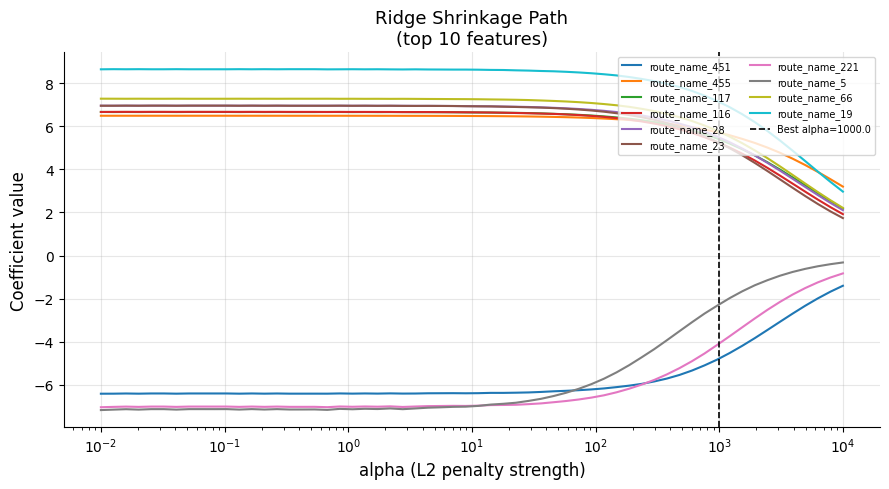

Saved: ridge_shrinkage_path.png


In [17]:
# Ridge shrinkage path: coefficients vs alpha
import numpy as np
from sklearn.linear_model import Ridge as RidgeModel

X_train_prep = final_model.named_steps['prep'].transform(X_train)

alphas_path = np.logspace(-2, 4, 60)
coefs_path  = []
for a in alphas_path:
    r = RidgeModel(alpha=a)
    r.fit(X_train_prep, y_train.values)
    coefs_path.append(r.coef_)
coefs_path = np.array(coefs_path).T  # shape: (n_features, n_alphas)

# Top 10 features by peak absolute coefficient
max_coef = np.max(np.abs(coefs_path), axis=1)
top_idx  = np.argsort(max_coef)[-10:]

ohe_names = list(final_model.named_steps['prep']
                 .named_transformers_['ohe']
                 .get_feature_names_out(CAT_FEATURES))
all_names = ohe_names + NUM_FEATURES

fig, ax = plt.subplots(figsize=(9, 5))
for i in top_idx:
    ax.semilogx(alphas_path, coefs_path[i], linewidth=1.5,
                label=all_names[i] if i < len(all_names) else f'feat_{i}')

ax.axvline(best_alpha, color='black', linestyle='--', linewidth=1.2,
           label=f'Best alpha={best_alpha}')
ax.set_xlabel('alpha (L2 penalty strength)', fontsize=12)
ax.set_ylabel('Coefficient value', fontsize=12)
ax.set_title('Ridge Shrinkage Path\n(top 10 features)', fontsize=13)
ax.legend(fontsize=7, loc='upper right', ncol=2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'ridge_shrinkage_path.png', dpi=150)
plt.show()
print('Saved: ridge_shrinkage_path.png')